In [3]:
import time
import numpy as np


# ============================================================
# VERSION 1 — VECTORIZED / OPTIMIZED
# ============================================================

def random_density_matrices(dim, N):
    """Generate N random density matrices simultaneously."""
    
    A = np.random.rand(N, dim, dim) + 1j * np.random.rand(N, dim, dim)

    # Make Hermitian
    A = (A + A.conj().transpose(0, 2, 1)) / 2

    # Positive semidefinite
    rho = A @ A.conj().transpose(0, 2, 1)

    # Normalize trace
    traces = np.trace(rho, axis1=1, axis2=2)[:, np.newaxis, np.newaxis]

    return rho / traces


class VectorizedGenerator:
    def __init__(self, d, N_training, N_test):
        self.d = d
        self.N_training = N_training
        self.N_test = N_test

    def generate_density_matrices(self):
        self.rho_training = random_density_matrices(self.d, self.N_training)
        self.rho_test = random_density_matrices(self.d, self.N_test)


# ============================================================
# VERSION 2 — LOOP-BASED
# ============================================================

def random_density_matrix(dim):
    """Generate a single random density matrix."""

    # Random complex matrix
    A = np.random.rand(dim, dim) + 1j * np.random.rand(dim, dim)

    # Make Hermitian
    A = (A + A.conj().T) / 2

    # Positive semidefinite
    A = A @ A.conj().T

    # Normalize trace
    rho = A / np.trace(A)

    return rho


class LoopGenerator:
    def __init__(self, d, N_training, N_test):
        self.d = d
        self.N_training = N_training
        self.N_test = N_test

    def generate_density_matrices(self):
        self.rho_training = np.array([
            random_density_matrix(self.d)
            for _ in range(self.N_training)
        ])

        self.rho_test = np.array([
            random_density_matrix(self.d)
            for _ in range(self.N_test)
        ])


# ============================================================
# BENCHMARK FUNCTION
# ============================================================

def benchmark(generator_class, d, N_training, N_test, repetitions=5):

    times = []

    for _ in range(repetitions):

        gen = generator_class(d, N_training, N_test)

        start = time.perf_counter()

        gen.generate_density_matrices()

        end = time.perf_counter()

        times.append(end - start)

    return np.mean(times), np.std(times)


# ============================================================
# RUN COMPARISON
# ============================================================

if __name__ == "__main__":

    d = 2
    N_training = 100000
    N_test = 10000

    print(f"\nBenchmarking with:")
    print(f"d = {d}")
    print(f"N_training = {N_training}")
    print(f"N_test = {N_test}\n")

    vec_mean, vec_std = benchmark(
        VectorizedGenerator,
        d,
        N_training,
        N_test
    )

    loop_mean, loop_std = benchmark(
        LoopGenerator,
        d,
        N_training,
        N_test
    )

    print("===== RESULTS =====")
    print(f"Vectorized version : {vec_mean:.4f} ± {vec_std:.4f} s")
    print(f"Loop version       : {loop_mean:.4f} ± {loop_std:.4f} s")

    speedup = loop_mean / vec_mean

    print(f"\nSpeedup: {speedup:.2f}x faster")


Benchmarking with:
d = 2
N_training = 100000
N_test = 10000

===== RESULTS =====
Vectorized version : 0.1025 ± 0.1034 s
Loop version       : 3.9509 ± 0.5487 s

Speedup: 38.55x faster


Shapes:
Loop generator: (1000, 2, 2)
Vectorized generator: (1000, 2, 2)

First 2 density matrices from Loop generator:
[[[0.52979325+2.22402149e-19j 0.49016785+2.20762436e-02j]
  [0.49016785-2.20762436e-02j 0.47020675-2.22402149e-19j]]

 [[0.23951546-1.00755628e-18j 0.37231111-1.69468742e-02j]
  [0.37231111+1.69468742e-02j 0.76048454+1.00755628e-18j]]]

First 2 density matrices from Vectorized generator:
[[[ 0.29600244+2.03911827e-18j -0.04603939-1.27269510e-01j]
  [-0.04603939+1.27269510e-01j  0.70399756-2.03911827e-18j]]

 [[ 0.88225101+7.03627610e-19j  0.13637228-5.26015468e-02j]
  [ 0.13637228+5.26015468e-02j  0.11774899-7.03627610e-19j]]]


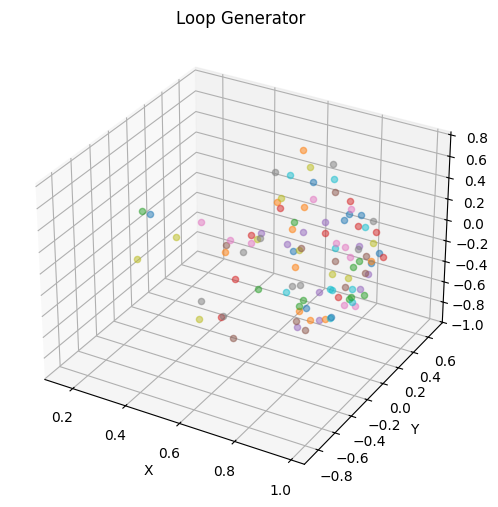

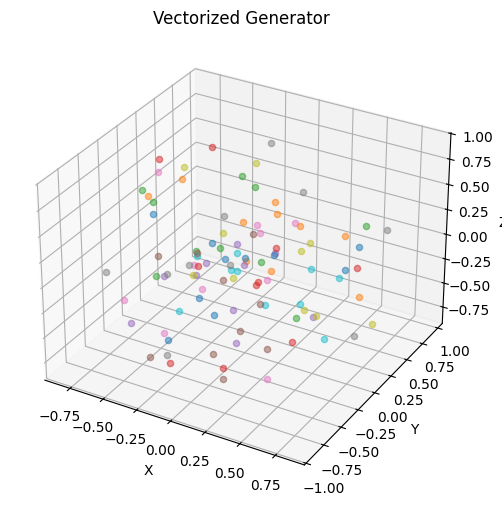

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# PARAMETERS
# ============================================================

d = 2
N_training = 1000


# ============================================================
# LOOP-BASED GENERATOR
# ============================================================

def random_density_matrix(dim):

    A = np.random.rand(dim, dim) + 1j * np.random.rand(dim, dim)

    # Hermitian
    A = (A + A.conj().T) / 2

    # Positive semidefinite
    A = A @ A.conj().T

    # Normalize
    rho = A / np.trace(A)

    return rho


# ============================================================
# VECTORIZED GENERATOR
# ============================================================

def random_density_matrices(dim, N):

    A = np.random.randn(N, dim, dim) + 1j * np.random.randn(N, dim, dim)

    # Hermitian
    A = (A + A.conj().transpose(0, 2, 1)) / 2

    # Positive semidefinite
    rho = A @ A.conj().transpose(0, 2, 1)

    # Normalize traces
    traces = np.trace(rho, axis1=1, axis2=2)[:, np.newaxis, np.newaxis]

    return rho / traces


# ============================================================
# GENERATE DATASETS
# ============================================================

rho_training = np.array([
    random_density_matrix(d)
    for _ in range(N_training)
])

rho_training_vec = random_density_matrices(d, N_training)


# ============================================================
# CHECK SHAPES
# ============================================================

print("Shapes:")
print(f"Loop generator: {rho_training.shape}")
print(f"Vectorized generator: {rho_training_vec.shape}")


# ============================================================
# PRINT FIRST 2 MATRICES
# ============================================================

print("\nFirst 2 density matrices from Loop generator:")
print(rho_training[:2])

print("\nFirst 2 density matrices from Vectorized generator:")
print(rho_training_vec[:2])


# ============================================================
# BLOCH SPHERE COORDINATES
# ============================================================

def bloch_coordinates(rho):
    """
    Convert a 2x2 density matrix into Bloch coordinates.
    """

    x = 2 * np.real(rho[0, 1])
    y = 2 * np.imag(rho[0, 1])

    # IMPORTANT: take real part
    z = np.real(rho[0, 0] - rho[1, 1])

    return x, y, z


# ============================================================
# PLOT LOOP GENERATOR
# ============================================================

fig1 = plt.figure(figsize=(7, 6))
ax1 = fig1.add_subplot(111, projection='3d')

for rho in rho_training[:100]:

    x, y, z = bloch_coordinates(rho)

    ax1.scatter(x, y, z, alpha=0.5)

ax1.set_title("Loop Generator")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

plt.show()


# ============================================================
# PLOT VECTORIZED GENERATOR
# ============================================================

fig2 = plt.figure(figsize=(7, 6))
ax2 = fig2.add_subplot(111, projection='3d')

for rho in rho_training_vec[:100]:

    x, y, z = bloch_coordinates(rho)

    ax2.scatter(x, y, z, alpha=0.5)

ax2.set_title("Vectorized Generator")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.show()

In [10]:
import numpy as np
import time
from timeit import repeat


class ExpectationBenchmark:
    def __init__(self, n_samples=10_000, dim=8, seed=42):
        rng = np.random.default_rng(seed)

        # Random complex density-like matrices
        A_train = rng.normal(size=(n_samples, dim, dim)) + 1j * rng.normal(size=(n_samples, dim, dim))
        A_test = rng.normal(size=(n_samples, dim, dim)) + 1j * rng.normal(size=(n_samples, dim, dim))

        # Make them Hermitian-ish just for realism
        self.rho_training = A_train @ np.conjugate(np.transpose(A_train, (0, 2, 1)))
        self.rho_test = A_test @ np.conjugate(np.transpose(A_test, (0, 2, 1)))

        # Random observable
        B = rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))
        self.observable = (B + B.conj().T) / 2

        self.expectation_training = None
        self.expectation_test = None

    # Original implementation
    def compute_expectation_values(self):
        if self.rho_training is None or self.rho_test is None:
            raise ValueError("Density matrices not generated yet.")

        self.expectation_training = np.real(
            np.array([np.trace(rho @ self.observable) for rho in self.rho_training])
        )

        self.expectation_test = np.real(
            np.array([np.trace(rho @ self.observable) for rho in self.rho_test])
        )

    # Vectorized implementation
    def compute_expectation_values_vec(self):
        if self.rho_training is None or self.rho_test is None:
            raise ValueError("Density matrices not generated yet.")

        self.expectation_training = np.real(
            np.einsum('nij,ji->n', self.rho_training, self.observable)
        )

        self.expectation_test = np.real(
            np.einsum('nij,ji->n', self.rho_test, self.observable)
        )


def benchmark():
    bench = ExpectationBenchmark(
        n_samples=20_000,
        dim=16,
    )

    # -------------------------
    # Correctness check
    # -------------------------
    bench.compute_expectation_values()
    train_ref = bench.expectation_training.copy()
    test_ref = bench.expectation_test.copy()

    bench.compute_expectation_values_vec()
    train_vec = bench.expectation_training.copy()
    test_vec = bench.expectation_test.copy()

    train_equal = np.allclose(train_ref, train_vec, atol=1e-12)
    test_equal = np.allclose(test_ref, test_vec, atol=1e-12)

    print("Correctness check")
    print("-----------------")
    print(f"Training outputs equal: {train_equal}")
    print(f"Test outputs equal:     {test_equal}")

    print("\nMax absolute differences:")
    print(f"Training: {np.max(np.abs(train_ref - train_vec)):.3e}")
    print(f"Test:     {np.max(np.abs(test_ref - test_vec)):.3e}")

    # -------------------------
    # Performance benchmark
    # -------------------------
    n_runs = 5

    loop_times = repeat(
        stmt="bench.compute_expectation_values()",
        repeat=n_runs,
        number=1,
        globals=globals() | {"bench": bench},
    )

    vec_times = repeat(
        stmt="bench.compute_expectation_values_vec()",
        repeat=n_runs,
        number=1,
        globals=globals() | {"bench": bench},
    )

    print("\nPerformance")
    print("-----------")
    print(f"Loop version:       {min(loop_times):.6f} s (best of {n_runs})")
    print(f"Vectorized version: {min(vec_times):.6f} s (best of {n_runs})")

    speedup = min(loop_times) / min(vec_times)
    print(f"Speedup: ~{speedup:.2f}x")


if __name__ == "__main__":
    benchmark()

Correctness check
-----------------
Training outputs equal: True
Test outputs equal:     True

Max absolute differences:
Training: 2.274e-13
Test:     1.705e-13

Performance
-----------
Loop version:       0.678858 s (best of 5)
Vectorized version: 0.035382 s (best of 5)
Speedup: ~19.19x
